<a href="https://colab.research.google.com/github/yassiehsani/git-tutorial/blob/main/UTC_Case_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
!git clone https://github.com/yassiehsani:/UTC2025.git

Cloning into 'UTC2025'...
fatal: could not read Username for 'https://github.com': No such device or address


In [37]:

!apt-get install git -y

!git config --global user.name "yassiehsani"
!git config --global user.email "yassiehsani@uchicago.edu"

!git clone https://github.com/yassiehsani/UTC2025
%cd your-repo  # move into the cloned repo


notebook_name = "UTC Case II.ipynb"
!cp /content/{notebook_name} .

!git add {notebook_name}
!git commit -m "Update from Colab"
!git push


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.12).
0 upgraded, 0 newly installed, 0 to remove and 30 not upgraded.
Cloning into 'UTC2025'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: 'your-repo # move into the cloned repo'
/content
cp: cannot stat '/content/UTC': No such file or directory
cp: cannot stat 'Case': No such file or directory
cp: cannot stat 'II.ipynb': No such file or directory
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [7]:
#import data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

file_path = "/content/drive/My Drive/Case2.csv"
df = pd.read_csv(file_path)

# Display first few rows
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Asset_1,Asset_2,Asset_3,Asset_4,Asset_5,Asset_6
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,1.000116,1.000057,1.000004,1.001425,0.999649,1.001650
2,0.999667,0.999739,1.000002,1.002474,0.999308,1.001552
3,1.000070,1.002696,1.000000,1.007441,1.001667,1.002308
4,1.000226,0.999711,1.000005,1.007110,1.001939,0.999043


In [44]:
class Allocator():
    window_length = 500
    def __init__(self, train_data):
        self.running_price_paths = train_data.copy()
        self.train_data = train_data.copy()
        self.tick_number = len(self.running_price_paths) - 1

    def allocate_portfolio(self, asset_prices):
        self.running_price_paths = pd.concat([self.running_price_paths, pd.DataFrame([asset_prices])], ignore_index=True)
        self.tick_number += 1

        idx = self.tick_number % 10
        if idx == 0:
            return np.zeros(6)

        recent_data = self.running_price_paths[['Asset_4', 'Asset_5', 'Asset_6']].tail(idx + 1).copy()
        returns = recent_data.pct_change().dropna()

        expected_returns = returns.mean()
        std_devs = returns.std().replace(0, np.nan)
        sharpe_scores = expected_returns / std_devs
        sharpe_scores = sharpe_scores.dropna()

        if sharpe_scores.empty:
            return np.zeros(6)

        best_asset = sharpe_scores.abs().idxmax()
        best_score = sharpe_scores[best_asset]

        # ✅ Static cutoff value
        target_return = 0.0017

        weight = np.sign(best_score) * min(abs(target_return / expected_returns[best_asset]), 1.0)

        weight_vector = np.zeros(6)
        asset_index = {'Asset_4': 3, 'Asset_5': 4, 'Asset_6': 5}[best_asset]
        weight_vector[asset_index] = weight

        return weight_vector


Mean: 0.001236, Std: 0.000974
Sharpe: 1.2690790738117728


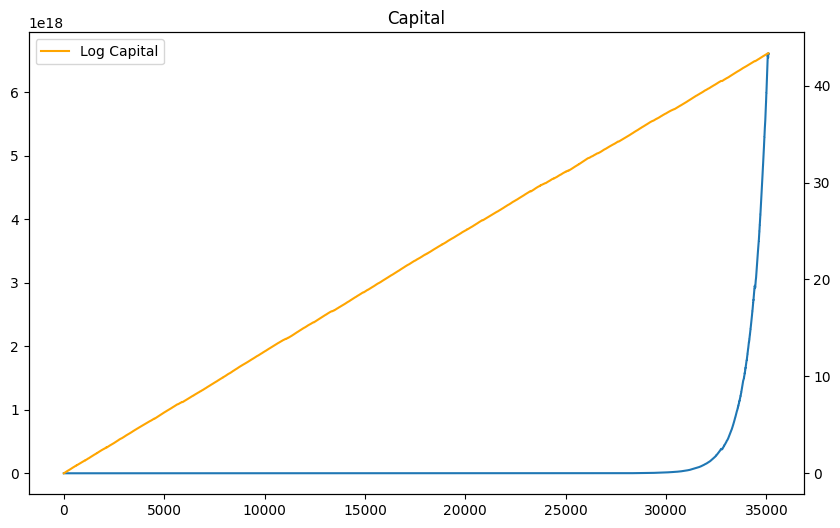

In [45]:
def grading(train_data, test_data):
    weights = np.full(shape=(len(test_data.index), 6), fill_value=0.0)
    alloc = Allocator(train_data)
    for i in range(len(test_data)):
        weights[i, :] = alloc.allocate_portfolio(test_data.iloc[i, :])
        if np.any(weights[i] < -1) or np.any(weights[i] > 1):
            raise Exception("Weights Outside of Bounds")

    capital = [1]
    for i in range(len(test_data) - 1):
        shares = capital[-1] * weights[i] / np.array(test_data.iloc[i, :])
        balance = capital[-1] - np.dot(shares, np.array(test_data.iloc[i, :]))
        net_change = np.dot(shares, np.array(test_data.iloc[i + 1, :]))
        capital.append(balance + net_change)

    capital = np.array(capital)
    returns = (capital[1:] - capital[:-1]) / capital[:-1]

    if np.std(returns) != 0:
        print(f"Mean: {np.mean(returns):.6f}, Std: {np.std(returns):.6f}")
        sharpe = np.mean(returns) / np.std(returns)
    else:
        sharpe = 0

    return sharpe, capital, weights

# Run strategy and plot
sharpe, capital, weights = grading(TRAIN, TEST)
print("Sharpe:", sharpe)

plt.figure(figsize=(10, 6))
plt.title("Capital")
plt.plot(np.arange(len(TEST)), capital, label='Capital')
plt.twinx()
plt.plot(np.arange(len(TEST)), np.log(capital), color='orange', label='Log Capital')
plt.legend()
plt.show()

Streaming output truncated to the last 5000 lines.
<ipython-input-41-0294d4b6e122>:18: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = recent_data.pct_change().dropna()
<ipython-input-41-0294d4b6e122>:18: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = recent_data.pct_change().dropna()
<ipython-input-41-0294d4b6e122>:18: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns =

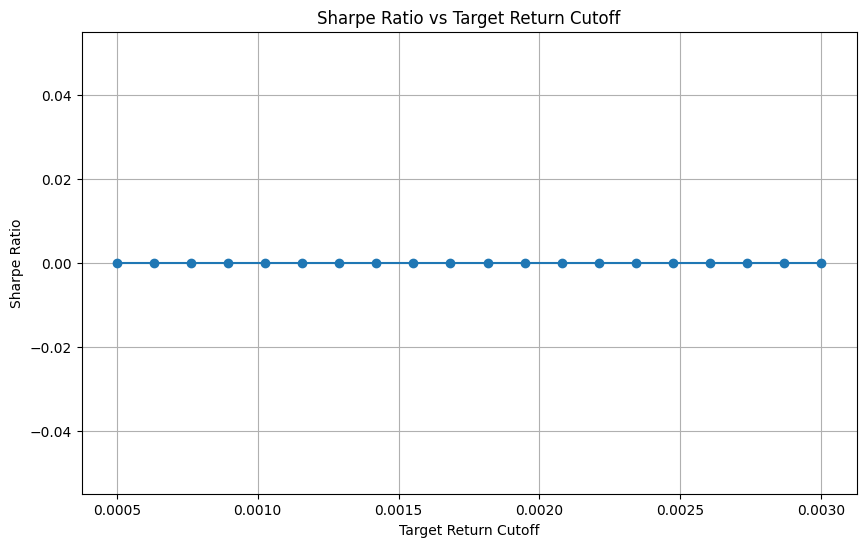

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Define your cutoff values
cutoff_values = np.linspace(0.0005, 0.003, 20)

# Function to run grading with dynamic cutoff
def grading_with_cutoff(train_data, test_data, target_return):
    weights = np.full(shape=(len(test_data.index), 6), fill_value=0.0)
    alloc = Allocator(train_data)
    alloc.target_return = target_return  # dynamically inject target return into the class

    for i in range(len(test_data)):
        weights[i, :] = alloc.allocate_portfolio(test_data.iloc[i, :].values)
        if np.any(weights[i] < -1) or np.any(weights[i] > 1):
            raise Exception("Weights Outside of Bounds")

    capital = [1]
    for i in range(len(test_data) - 1):
        shares = capital[-1] * weights[i] / np.array(test_data.iloc[i, :])
        balance = capital[-1] - np.dot(shares, np.array(test_data.iloc[i, :]))
        net_change = np.dot(shares, np.array(test_data.iloc[i + 1, :]))
        capital.append(balance + net_change)

    capital = np.array(capital)
    returns = (capital[1:] - capital[:-1]) / capital[:-1]

    if np.std(returns) != 0:
        return np.mean(returns) / np.std(returns)
    else:
        return 0

# Run strategy for each cutoff value on a shortened test set for speed
sharpes = [grading_with_cutoff(TRAIN, TEST.head(500), cutoff) for cutoff in cutoff_values]

# Plot it
plt.figure(figsize=(10, 6))
plt.plot(cutoff_values, sharpes, marker='o')
plt.title("Sharpe Ratio vs Target Return Cutoff")
plt.xlabel("Target Return Cutoff")
plt.ylabel("Sharpe Ratio")
plt.grid(True)
plt.show()
